# Import Data and Segment into train, test

In [109]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np



PATHIM = "data//mnist_large//images.csv"
PATHLB = "data//mnist_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

""" Create a test and train set """
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.30, random_state=42, stratify=labels)


# Check Data

In [110]:
print(f"Shape images: {images.shape}")
print(f"Shape labels: {labels.shape}")

print(f"Shape train: {x_train.shape}")
print(f"Shape train target: {y_train.shape}")

print(f"Shape test: {x_test.shape}")
print(f"Shape test target: {y_test.shape}")


# To check the class labels:
print(f"{y_train["label"].value_counts()}")
print(f"{y_test["label"].value_counts()}")


Shape images: (10000, 784)
Shape labels: (10000, 1)
Shape train: (7000, 784)
Shape train target: (7000, 1)
Shape test: (3000, 784)
Shape test target: (3000, 1)
label
8    700
2    700
0    700
5    700
9    700
6    700
4    700
1    700
7    700
3    700
Name: count, dtype: int64
label
1    300
2    300
3    300
4    300
0    300
5    300
9    300
7    300
6    300
8    300
Name: count, dtype: int64


# Perform Dimensional Reduction

132370.4327795989


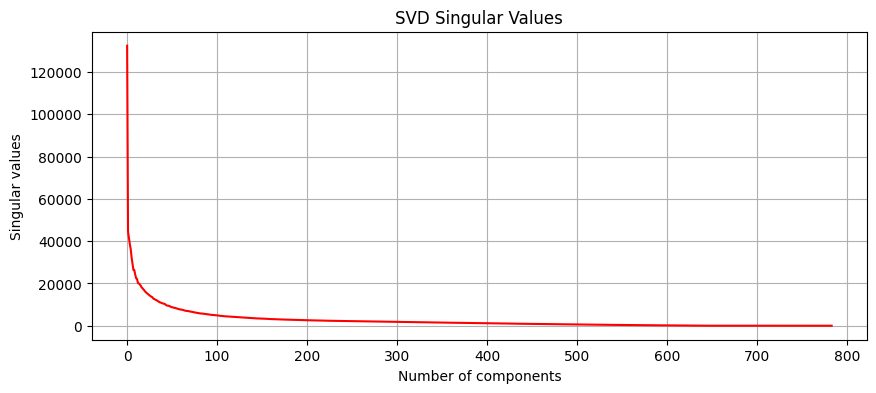

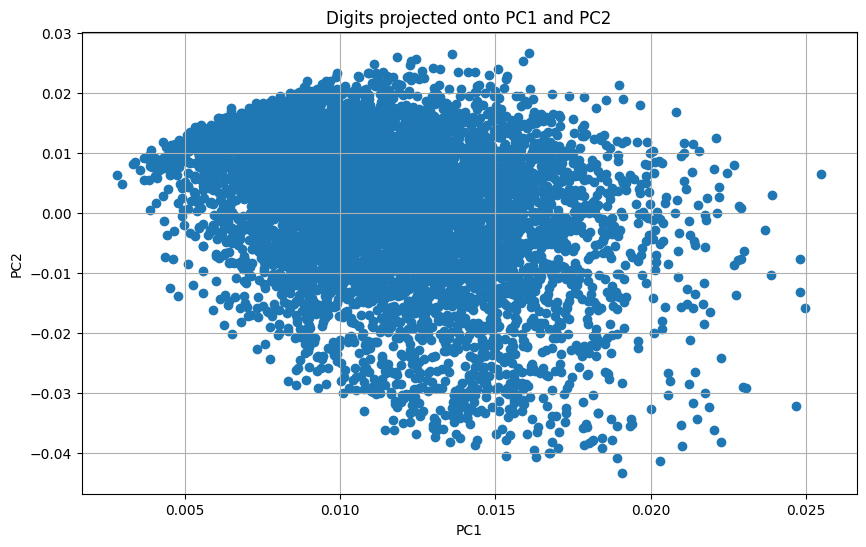

In [111]:
# Do the Singular Value Decomposition
#U is Orthogonal and has Left Singular Vectors
#Technically S should be a diagonal matrix with descending singular values
#(Although S is a list here) 
# V is Orthogonal and has Right Singular Vectors
U, S, Vt = np.linalg.svd(x_train, full_matrices=True)


print(S[0])

# Plot the singular values against 
plt.figure(figsize=(10, 4))
#This works because linalg.svd returns S as list not a matrix
plt.plot(S, 'r-')
plt.xlabel('Number of components')
plt.ylabel('Singular values')
plt.title('SVD Singular Values')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(U[:, 0], U[:, 1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Digits projected onto PC1 and PC2')
plt.grid(True)
plt.show()

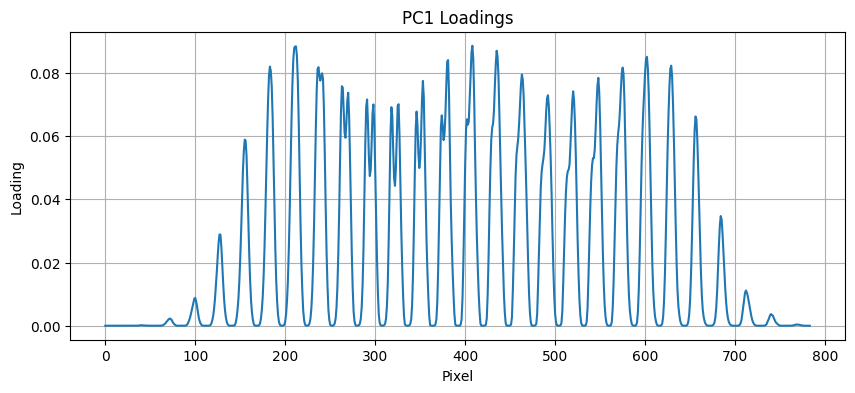

In [112]:
# Plot the loading vector for PC1
plt.figure(figsize=(10, 4))
plt.plot(Vt[0, :])
plt.xlabel('Pixel')
plt.ylabel('Loading')
plt.title('PC1 Loadings')
plt.grid(True)
plt.show()


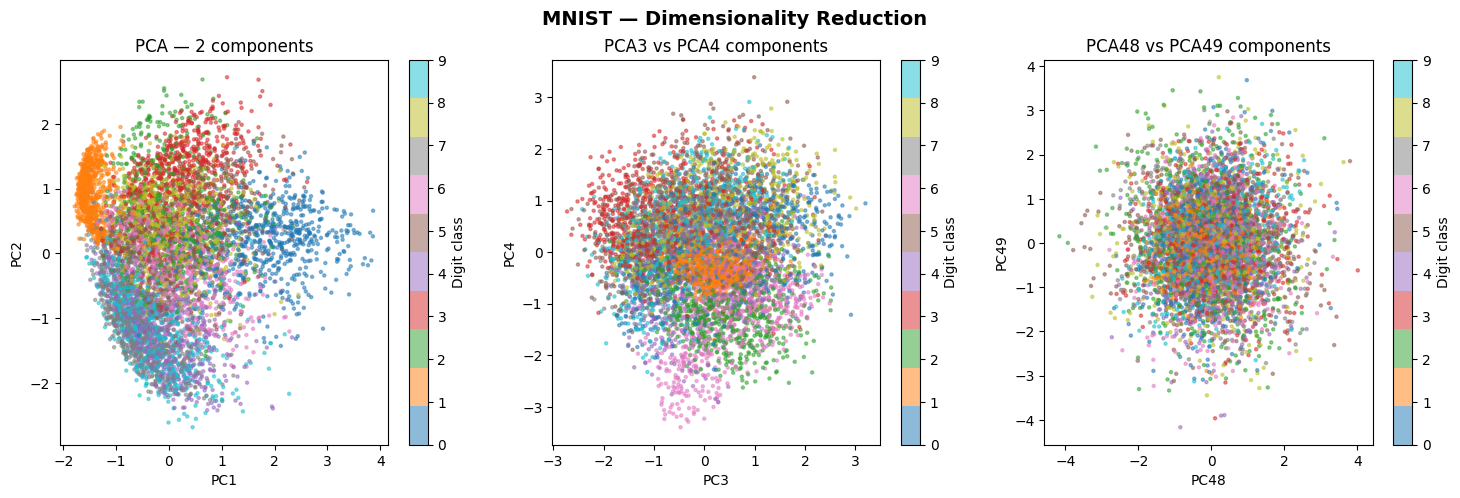

In [113]:
from sklearn.decomposition import PCA


#PCA with 50 Conponents, Whiten = rescale around zero with unit variance
#Compared to SVD above, PCA always centers the data
pca50 = PCA(n_components=50, svd_solver='full', whiten=True)
pca50_train = pca50.fit_transform(x_train)
pca50_test = pca50.transform(x_test)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MNIST — Dimensionality Reduction", fontsize=14, fontweight="bold")

# PCA1 v PCA2 scatter
sc1 = axes[0].scatter(pca50_train[:, 0], pca50_train[:, 1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[0].set_title("PCA — 2 components")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="Digit class")

# PCA3 v PCA4 scatter
sc1 = axes[1].scatter(pca50_train[:, 2], pca50_train[:, 3],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[1].set_title("PCA3 vs PCA4 components")
axes[1].set_xlabel("PC3"); axes[1].set_ylabel("PC4")
plt.colorbar(sc1, ax=axes[1], label="Digit class")

# PCA5 v PCA6 scatter
sc1 = axes[2].scatter(pca50_train[:, -2], pca50_train[:, -1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[2].set_title("PCA48 vs PCA49 components")
axes[2].set_xlabel("PC48"); axes[2].set_ylabel("PC49")
plt.colorbar(sc1, ax=axes[2], label="Digit class")


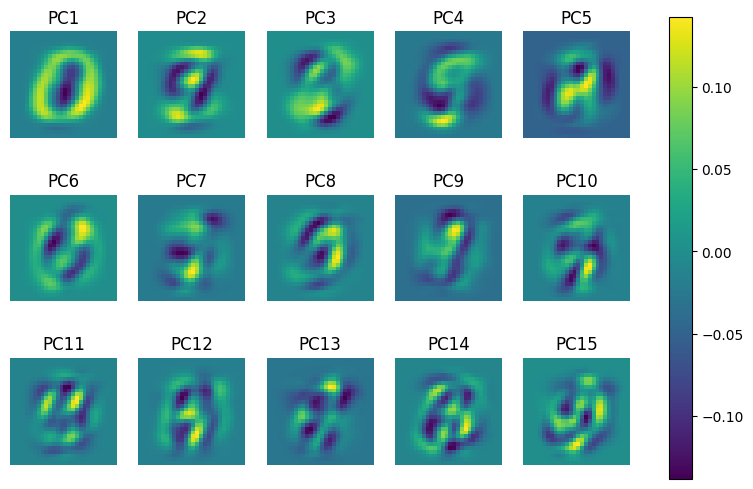

In [114]:

fig, axes = plt.subplots(3,5, figsize=(10,6))

for i, ax in enumerate(axes.flat):
    pc = pca50.components_[i]
    pc_image = pc.reshape(28,28)

    im = ax.imshow(pc_image, cmap = 'viridis')
    ax.set_title(f"PC{i+1}")
    ax.axis('off')
fig.colorbar(im, ax=axes.ravel())
plt.show()

# KNN - Cross Validation

In [115]:
from sklearn.model_selection import StratifiedKFold

five_fold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2547)

for train_idx, val_idx in five_fold_cv.split(pca50_train, y_train.values):
    pca50_train_fold = pca50_train[train_idx]
    y_train_fold = y_train.values[train_idx]
    pca50_val_fold = pca50_train[val_idx]
    y_val_fold = y_train.values[val_idx]



In [116]:
# Make sure train and val indices don't overlap
assert len(set(train_idx) & set(val_idx)) == 0

In [117]:
from sklearn.neighbors import KNeighborsClassifier

# Apply to train

k_vals = [2*x+1 for x in range(20)]
k_error_rate = {}

for n in k_vals:
    k_error_rate[f"{n}"] = []

k_var = {}

for n in k_vals:
    print(n)

    #y_train is formatted weird so have to unravel
    for train_idx, val_idx in five_fold_cv.split(pca50_train, np.ravel(y_train)):
        pca50_train_fold = pca50_train[train_idx]
        y_train_fold = np.ravel(y_train)[train_idx]
        pca50_val_fold = pca50_train[val_idx]
        y_val_fold = np.ravel(y_train)[val_idx]

        #fit model
        neigh = KNeighborsClassifier(n_neighbors=n, metric= "euclidean")
        neigh.fit(pca50_train_fold, y_train_fold)

        # Predict and calculate errors
        k_error_rate[f"{n}"].append(np.mean(neigh.predict(pca50_val_fold) != y_val_fold))



for n in k_vals:
    print(f"{n}: {k_error_rate[f"{n}"]}")



1
3
5
7
9
11
13
15
17
19
21
23
25
27
29
31
33
35
37
39
1: [np.float64(0.07), np.float64(0.06928571428571428), np.float64(0.07285714285714286), np.float64(0.07428571428571429), np.float64(0.08285714285714285)]
3: [np.float64(0.07642857142857143), np.float64(0.07142857142857142), np.float64(0.07214285714285715), np.float64(0.07428571428571429), np.float64(0.07428571428571429)]
5: [np.float64(0.07571428571428572), np.float64(0.07857142857142857), np.float64(0.06857142857142857), np.float64(0.06928571428571428), np.float64(0.08)]
7: [np.float64(0.08), np.float64(0.08642857142857142), np.float64(0.07428571428571429), np.float64(0.07928571428571428), np.float64(0.08642857142857142)]
9: [np.float64(0.08142857142857143), np.float64(0.08214285714285714), np.float64(0.08214285714285714), np.float64(0.085), np.float64(0.09)]
11: [np.float64(0.08214285714285714), np.float64(0.08357142857142857), np.float64(0.07571428571428572), np.float64(0.085), np.float64(0.09285714285714286)]
13: [np.float64(0.

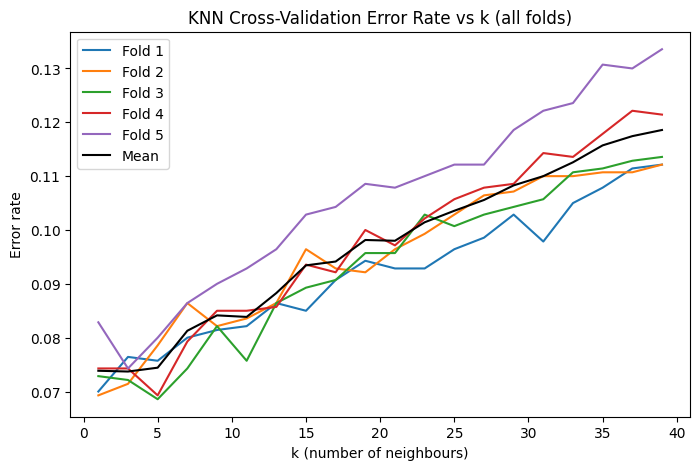

In [118]:
plt.figure(figsize=(8, 5))

# Plot each fold as a separate line
n_folds = len(k_error_rate[f"{k_vals[0]}"])
for fold in range(n_folds):
    fold_errors = [k_error_rate[f"{n}"][fold] for n in k_vals]
    plt.plot(k_vals, fold_errors,  label=f'Fold {fold+1}')

# Plot mean on top
k_means = [np.mean(k_error_rate[f"{n}"]) for n in k_vals]
plt.plot(k_vals, k_means, color='black', label='Mean', zorder=5)

plt.xlabel('k (number of neighbours)')
plt.ylabel('Error rate')
plt.title('KNN Cross-Validation Error Rate vs k (all folds)')
plt.legend()
plt.show()






### No U-shaped error. Maybe they cluster enough for k 1 to 5, but after that point the bias from over-smoothing becomes too much


--- PCA dimensions: 10 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k=13
  k=15
  k=17
  k=19
  k=21
  k=23
  k=25
  k=27
  k=29
  k=31
  k=33
  k=35
  k=37
  k=39
  k=41
  k=43
  k=45
  k=47
  k=49
  k=51
  k=53
  k=55
  k=57
  k=59

--- PCA dimensions: 20 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k=13
  k=15
  k=17
  k=19
  k=21
  k=23
  k=25
  k=27
  k=29
  k=31
  k=33
  k=35
  k=37
  k=39
  k=41
  k=43
  k=45
  k=47
  k=49
  k=51
  k=53
  k=55
  k=57
  k=59

--- PCA dimensions: 25 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k=13
  k=15
  k=17
  k=19
  k=21
  k=23
  k=25
  k=27
  k=29
  k=31
  k=33
  k=35
  k=37
  k=39
  k=41
  k=43
  k=45
  k=47
  k=49
  k=51
  k=53
  k=55
  k=57
  k=59

--- PCA dimensions: 30 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k=13
  k=15
  k=17
  k=19
  k=21
  k=23
  k=25
  k=27
  k=29
  k=31
  k=33
  k=35
  k=37
  k=39
  k=41
  k=43
  k=45
  k=47
  k=49
  k=51
  k=53
  k=55
  k=57
  k=59

--- PCA dimensions: 35 ---
  k=1
  k=3
  k=5
  k=7
  k=9
  k=11
  k

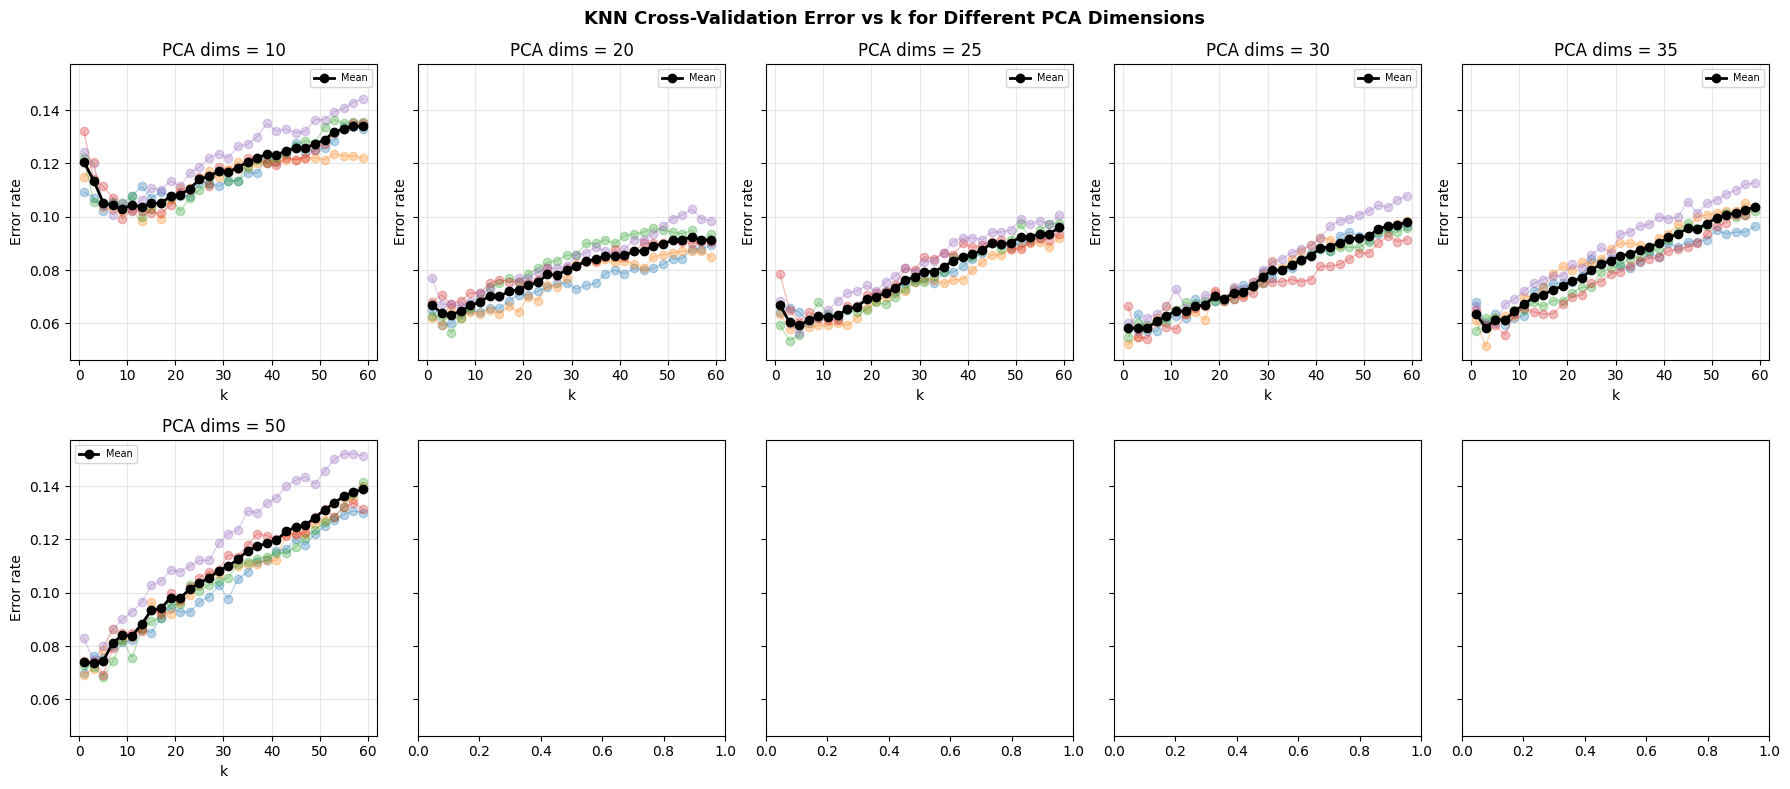

In [119]:
dims   = [10, 20, 25, 30, 35, 50]
k_vals = [2*x+1 for x in range(30)]

all_errors = {f"{d}": {f"{n}": [] for n in k_vals} for d in dims}

for d in dims:
    print(f"\n--- PCA dimensions: {d} ---")

    # Fit PCA with correct n_components for this iteration
    pca = PCA(n_components=d, svd_solver='full', whiten=True)
    pca_train = pca.fit_transform(x_train)

    for n in k_vals:
        print(f"  k={n}")

        for train_idx, val_idx in five_fold_cv.split(pca_train, np.ravel(y_train)):
            # Slice the dimension-specific PCA arrays
            pca_train_fold = pca_train[train_idx]
            y_train_fold   = np.ravel(y_train)[train_idx]
            pca_val_fold   = pca_train[val_idx]
            y_val_fold     = np.ravel(y_train)[val_idx]

            # Fit and find CV Error
            neigh = KNeighborsClassifier(n_neighbors=n, metric="euclidean")
            neigh.fit(pca_train_fold, y_train_fold)
            error = np.mean(neigh.predict(pca_val_fold) != y_val_fold)
            all_errors[f"{d}"][f"{n}"].append(error)

# plot
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for i, d in enumerate(dims):
    ax = axes[i]
    
    # Individual fold errors
    n_folds = len(all_errors[f"{d}"][f"{k_vals[0]}"])
    for fold in range(n_folds):
        fold_errors = [all_errors[f"{d}"][f"{n}"][fold] for n in k_vals]
        ax.plot(k_vals, fold_errors, 'o-', alpha=0.3, lw=1)

    # Mean CV error
    mean_errors = [np.mean(all_errors[f"{d}"][f"{n}"]) for n in k_vals]
    ax.plot(k_vals, mean_errors, 'o-', color='black', lw=2, label='Mean')


    ax.set_title(f"PCA dims = {d}")
    ax.set_xlabel("k")
    ax.set_ylabel("Error rate")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)

plt.suptitle("KNN Cross-Validation Error vs k for Different PCA Dimensions",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

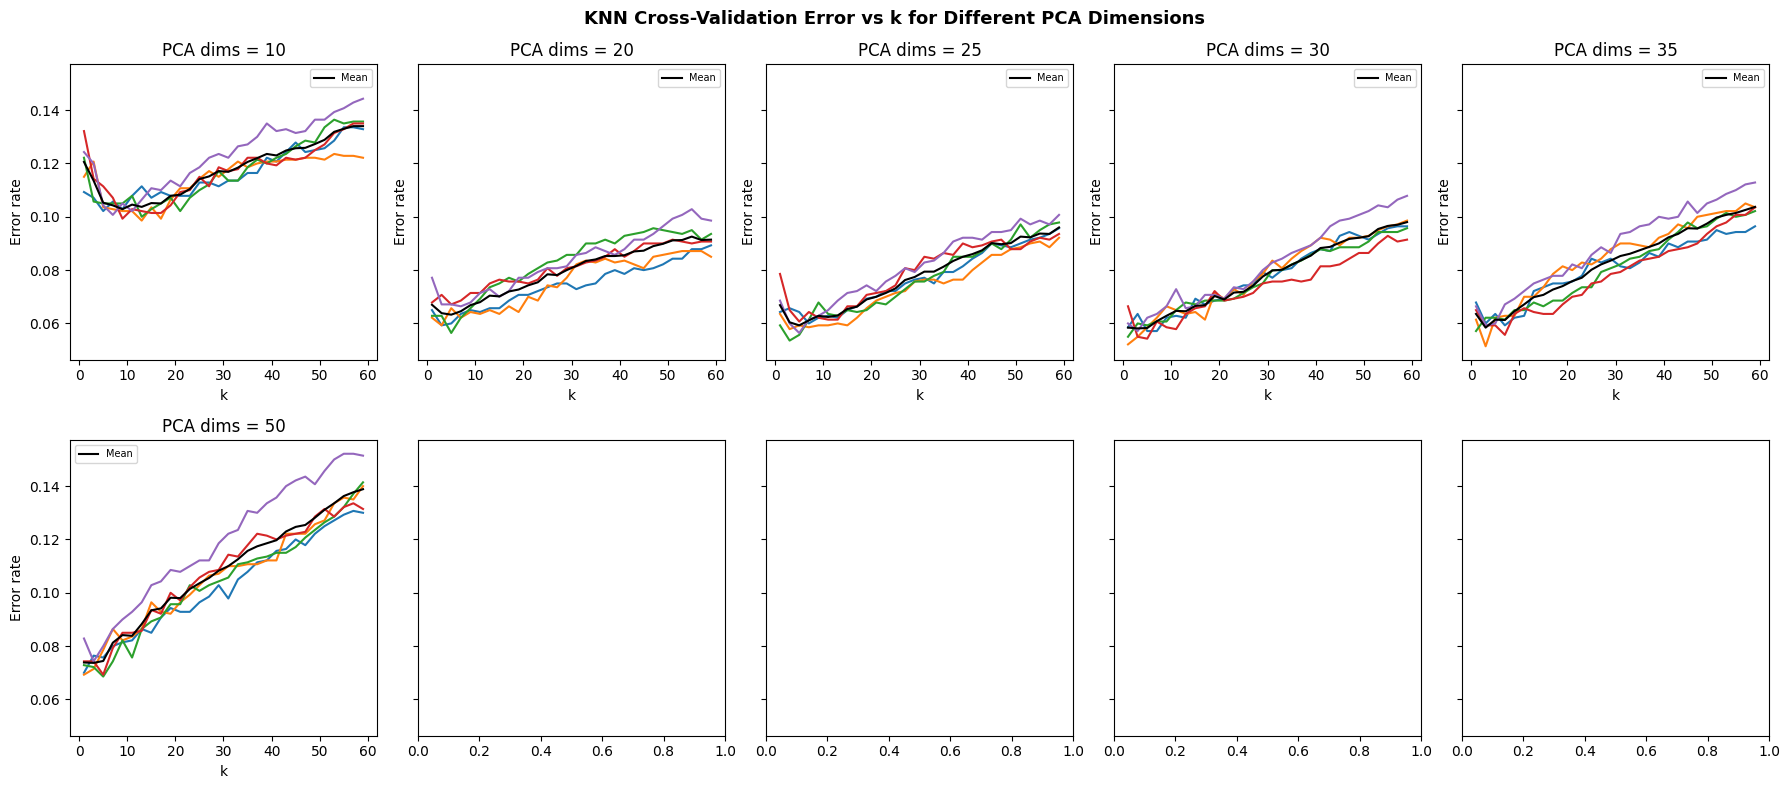

In [120]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for i, d in enumerate(dims):
    ax = axes[i]
    
    # Individual fold lines
    n_folds = len(all_errors[f"{d}"][f"{k_vals[0]}"])
    for fold in range(n_folds):
        fold_errors = [all_errors[f"{d}"][f"{n}"][fold] for n in k_vals]
        ax.plot(k_vals, fold_errors)

    # Mean line
    mean_errors = [np.mean(all_errors[f"{d}"][f"{n}"]) for n in k_vals]
    ax.plot(k_vals, mean_errors,  color='black', label='Mean')

    ax.set_title(f"PCA dims = {d}")
    ax.set_xlabel("k")
    ax.set_ylabel("Error rate")
    ax.legend(fontsize=7)

plt.suptitle("KNN Cross-Validation Error vs k for Different PCA Dimensions",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

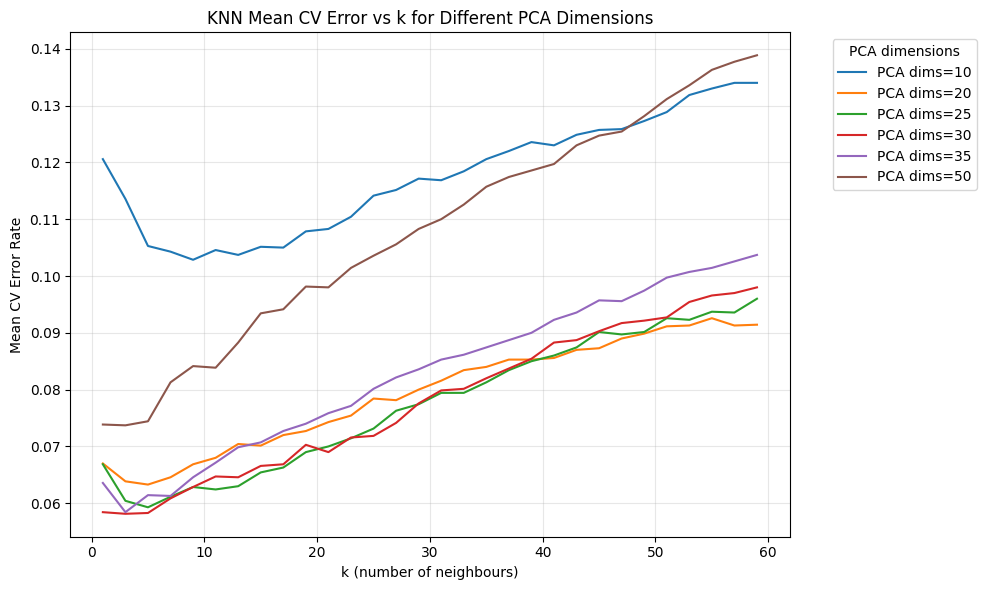

In [121]:
plt.figure(figsize=(10, 6))

for d in dims:
    mean_errors = [np.mean(all_errors[f"{d}"][f"{n}"]) for n in k_vals]
    plt.plot(k_vals, mean_errors, label=f"PCA dims={d}")

plt.xlabel("k (number of neighbours)")
plt.ylabel("Mean CV Error Rate")
plt.title("KNN Mean CV Error vs k for Different PCA Dimensions")
plt.legend(title="PCA dimensions", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Logistic Regression

In [122]:
from sklearn.linear_model import LogisticRegression

##########################
# Note - SKLEARN USES Maximum A Posteriori (MAP) estimation not MLE as discussed in the book
##########################

five_fold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2547)

logistic_error_rates = []
logistic_val_preds = []
logistic_val_actual = []

for train_idx, val_idx in five_fold_cv.split(pca50_train, np.ravel(y_train)):
    pca50_train_fold = pca50_train[train_idx]
    y_train_fold = np.ravel(y_train)[train_idx]
    pca50_val_fold = pca50_train[val_idx]
    y_val_fold = np.ravel(y_train)[val_idx]

    logistic_model = LogisticRegression(max_iter=2_000)
    logistic_model.fit(pca50_train_fold, y_train_fold)
    
    logistic_val_preds.append(logistic_model.predict(pca50_val_fold))
    logistic_val_actual.append(y_val_fold)

    logistic_error_rates.append(np.mean(logistic_model.predict(pca50_val_fold) != y_val_fold))

print(f"Error Rates: {logistic_error_rates}")
print(f"Mean Error Rate: {np.mean(logistic_error_rates)}")


Error Rates: [np.float64(0.10714285714285714), np.float64(0.10714285714285714), np.float64(0.09214285714285714), np.float64(0.11142857142857143), np.float64(0.09857142857142857)]
Mean Error Rate: 0.10328571428571427


## Classification Accuracy for Logistic Regression

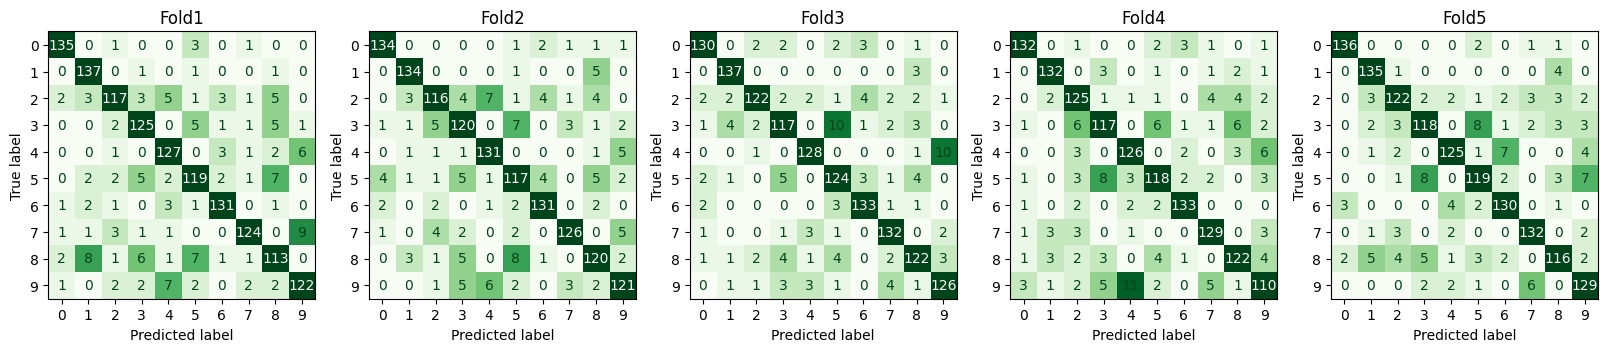

In [134]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


fig, axes = plt.subplots(1,5, figsize = (20,20))


for  i in range(5):

    y_pred = logistic_val_preds[i]
    y_true = logistic_val_actual[i]


    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[i],cmap='Greens', values_format="d",colorbar=False)

    #fix a max color at 12
    im = axes[i].images[0]
    im.set_clim(0, 12)


    axes[i].set_title(f"Fold{i+1}")

plt.show()

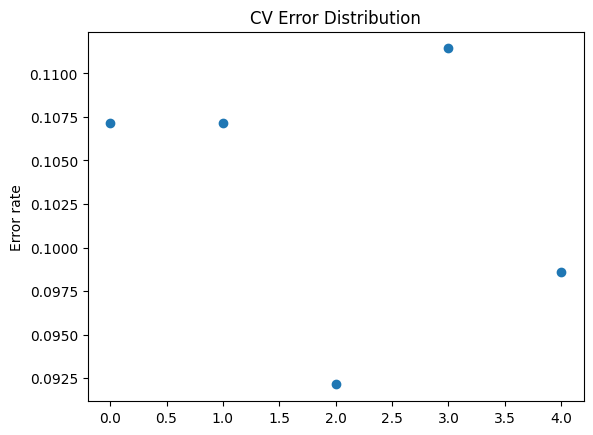

In [135]:
plt.plot(logistic_error_rates, 'o')
plt.title("CV Error Distribution")
plt.ylabel("Error rate")
plt.show()

# Support Vector Machine

In [127]:
from sklearn import svm

svm_error_rates = []
svm_preds = []
svm_actual = []

for train_idx, val_idx in five_fold_cv.split(pca50_train, np.ravel(y_train)):
    pca50_train_fold = pca50_train[train_idx]
    y_train_fold = np.ravel(y_train)[train_idx]
    pca50_val_fold = pca50_train[val_idx]
    y_val_fold = np.ravel(y_train)[val_idx]

    svm_model = svm.SVC(kernel="linear").fit(pca50_train_fold,y_train_fold)

    svm_preds.append(svm_model.predict(pca50_val_fold))
    svm_actual.append(y_val_fold)

    svm_error_rates.append(np.mean(svm_model.predict(pca50_val_fold) != y_val_fold))
    
print(svm_error_rates)
print(np.mean(svm_error_rates))


[np.float64(0.09214285714285714), np.float64(0.08), np.float64(0.08357142857142857), np.float64(0.1), np.float64(0.08642857142857142)]
0.08842857142857144


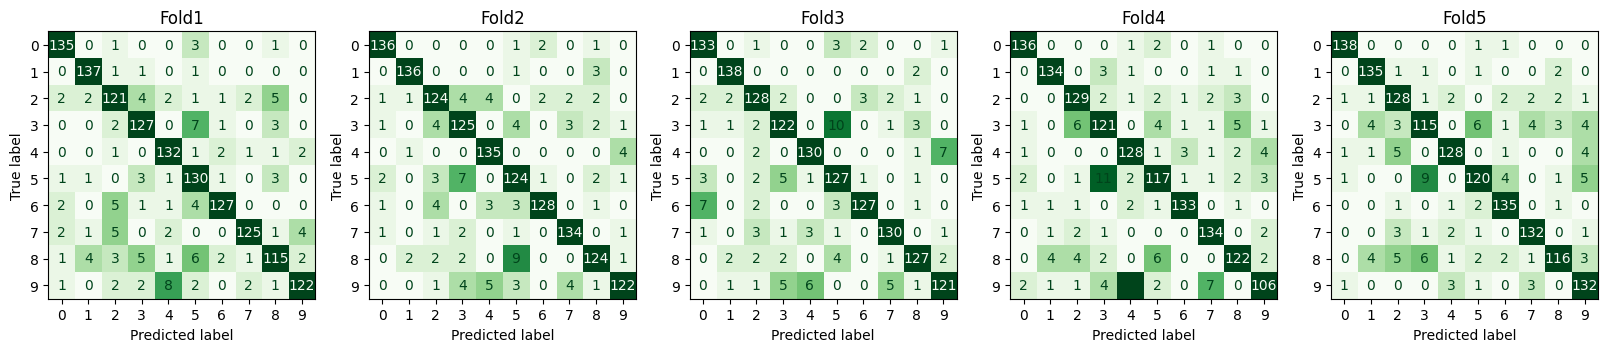

In [129]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


fig, axes = plt.subplots(1,5, figsize = (20,20))


for  i in range(5):

    y_pred = svm_preds[i]
    y_true = svm_actual[i]


    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[i],cmap='Greens', values_format="d",colorbar=False)

    #fix a max color at 12
    im = axes[i].images[0]
    im.set_clim(0, 12)


    axes[i].set_title(f"Fold{i+1}")

plt.show()

# Part 2 Theme 3
## Set up PCA

In [ ]:
# Do Full Dimension, 50 Principal Components and Kernel PCA with 50 components
from sklearn.decomposition import KernelPCA


full_train = x_train
full_test = x_test

pca50 = PCA(n_components=50, svd_solver='full', whiten=True)
pca50_train = pca50.fit_transform(x_train)
pca50_test = pca50.transform(x_test)



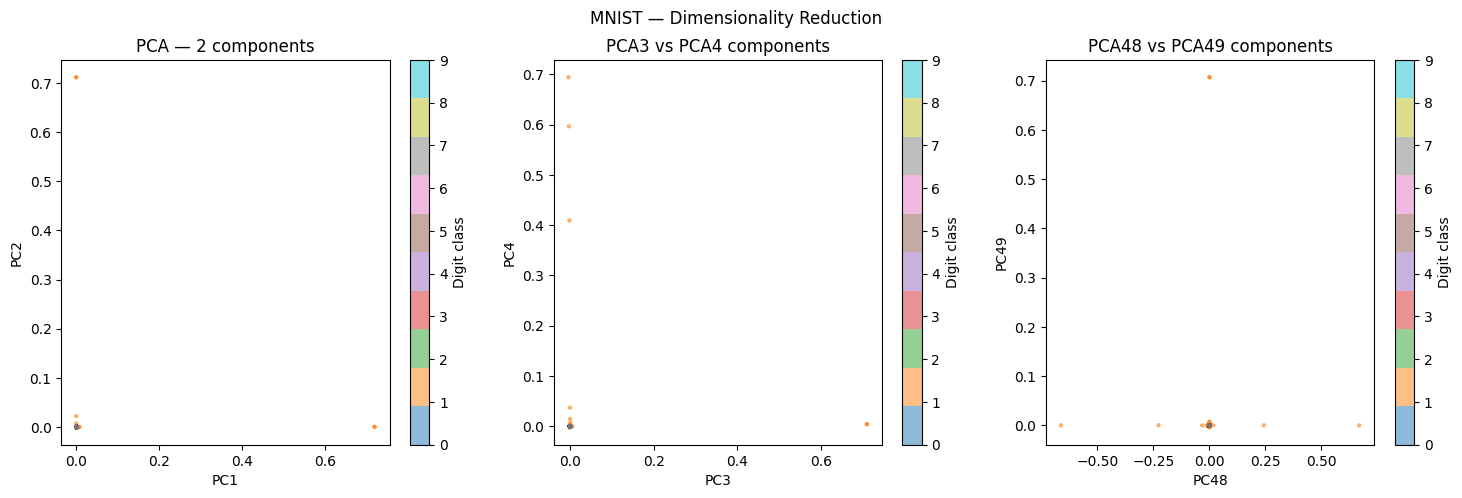

In [156]:
from sklearn.preprocessing import StandardScaler

#Need to Scale first! So that
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

kpca = KernelPCA(n_components=50, kernel='rbf', gamma=0.5)

kpca50_train = kpca.fit_transform(x_train_scaled)
kpca50_test = kpca.transform(x_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MNIST — Dimensionality Reduction")

# PCA1 v PCA2 scatter
sc1 = axes[0].scatter(kpca50_train[:, 0], kpca50_train[:, 1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[0].set_title("PCA — 2 components")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="Digit class")

# PCA3 v PCA4 scatter
sc1 = axes[1].scatter(kpca50_train[:, 2], kpca50_train[:, 3],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[1].set_title("PCA3 vs PCA4 components")
axes[1].set_xlabel("PC3"); axes[1].set_ylabel("PC4")
plt.colorbar(sc1, ax=axes[1], label="Digit class")

# PCA5 v PCA6 scatter
sc1 = axes[2].scatter(kpca50_train[:, -2], kpca50_train[:, -1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[2].set_title("PCA48 vs PCA49 components")
axes[2].set_xlabel("PC48"); axes[2].set_ylabel("PC49")
plt.colorbar(sc1, ax=axes[2], label="Digit class")

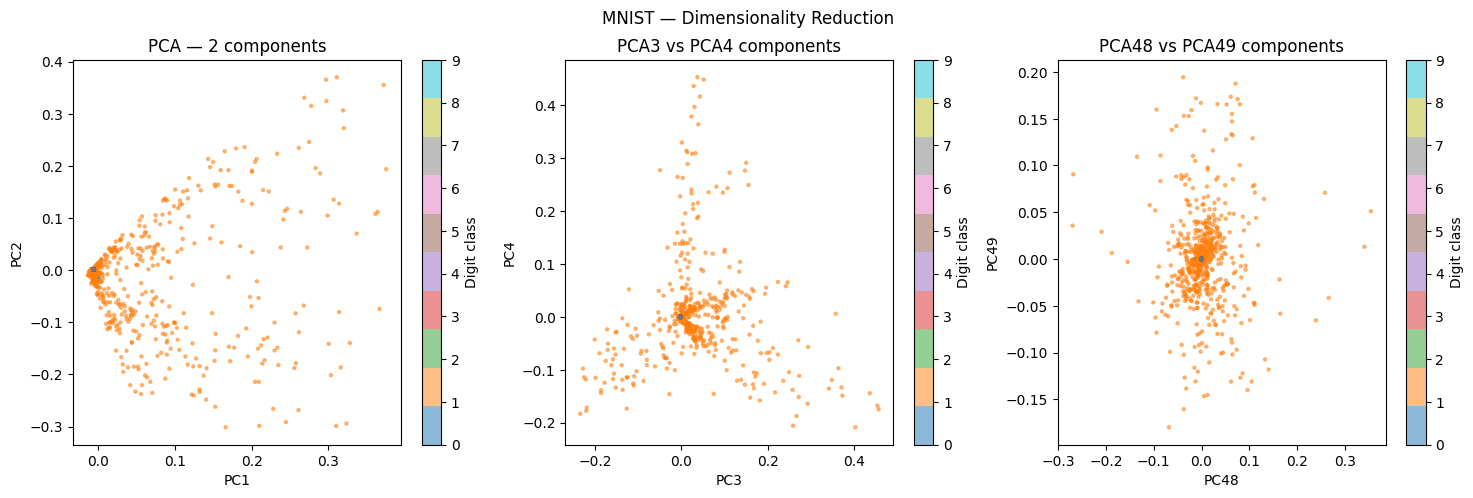

In [157]:
from sklearn.preprocessing import StandardScaler

#Need to Scale first! So that
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

kpca = KernelPCA(n_components=50, kernel='rbf', gamma=0.05)

kpca50_train = kpca.fit_transform(x_train_scaled)
kpca50_test = kpca.transform(x_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MNIST — Dimensionality Reduction")

# PCA1 v PCA2 scatter
sc1 = axes[0].scatter(kpca50_train[:, 0], kpca50_train[:, 1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[0].set_title("PCA — 2 components")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="Digit class")

# PCA3 v PCA4 scatter
sc1 = axes[1].scatter(kpca50_train[:, 2], kpca50_train[:, 3],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[1].set_title("PCA3 vs PCA4 components")
axes[1].set_xlabel("PC3"); axes[1].set_ylabel("PC4")
plt.colorbar(sc1, ax=axes[1], label="Digit class")

# PCA5 v PCA6 scatter
sc1 = axes[2].scatter(kpca50_train[:, -2], kpca50_train[:, -1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[2].set_title("PCA48 vs PCA49 components")
axes[2].set_xlabel("PC48"); axes[2].set_ylabel("PC49")
plt.colorbar(sc1, ax=axes[2], label="Digit class")

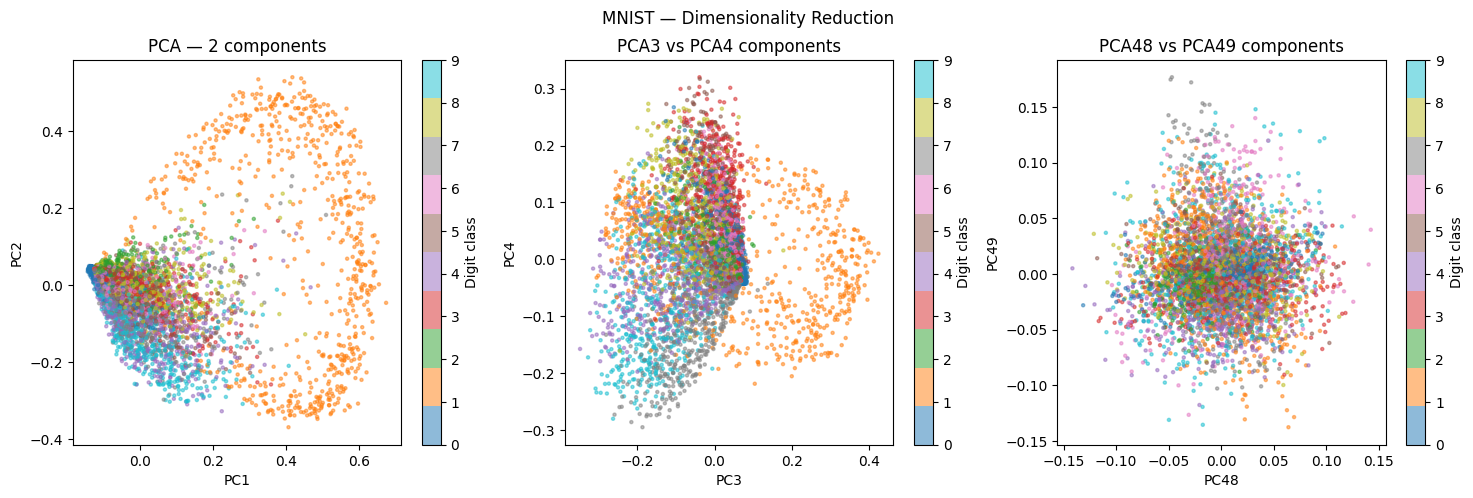

In [162]:
from sklearn.preprocessing import StandardScaler

#Need to Scale first! So that
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

kpca = KernelPCA(n_components=50, kernel='rbf', gamma=0.005)

kpca50_train = kpca.fit_transform(x_train_scaled)
kpca50_test = kpca.transform(x_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MNIST — Dimensionality Reduction")

# PCA1 v PCA2 scatter
sc1 = axes[0].scatter(kpca50_train[:, 0], kpca50_train[:, 1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[0].set_title("PCA — 2 components")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="Digit class")

# PCA3 v PCA4 scatter
sc1 = axes[1].scatter(kpca50_train[:, 2], kpca50_train[:, 3],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[1].set_title("PCA3 vs PCA4 components")
axes[1].set_xlabel("PC3"); axes[1].set_ylabel("PC4")
plt.colorbar(sc1, ax=axes[1], label="Digit class")

# PCA5 v PCA6 scatter
sc1 = axes[2].scatter(kpca50_train[:, -2], kpca50_train[:, -1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[2].set_title("PCA48 vs PCA49 components")
axes[2].set_xlabel("PC48"); axes[2].set_ylabel("PC49")
plt.colorbar(sc1, ax=axes[2], label="Digit class")

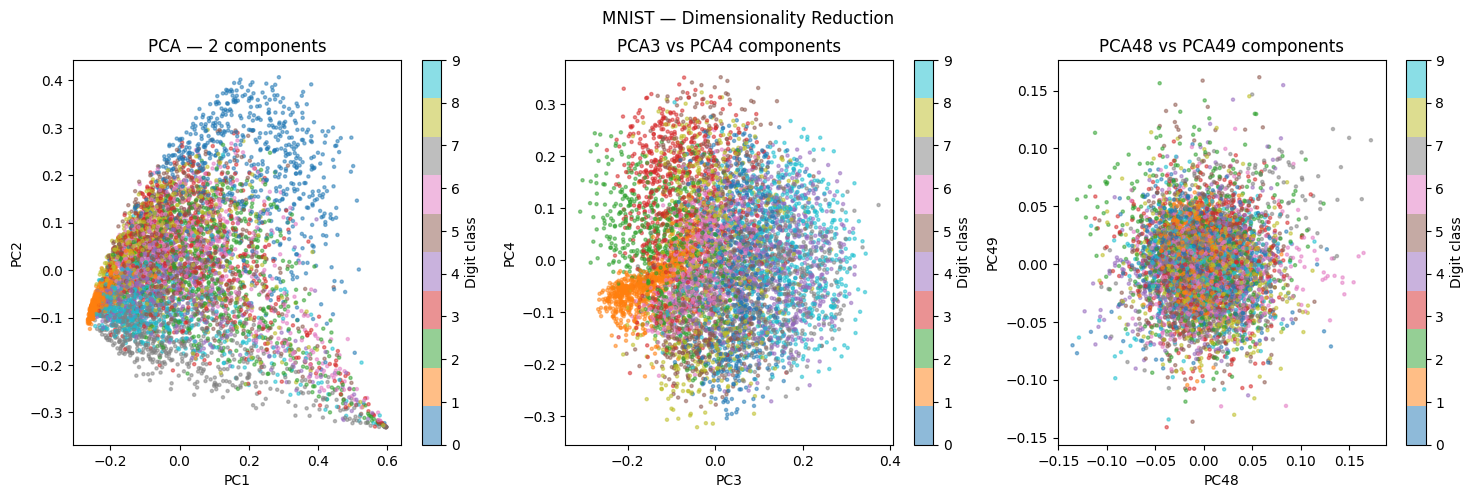

In [171]:
from sklearn.preprocessing import StandardScaler

#Need to Scale first! So that
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

pca50

kpca = KernelPCA(n_components=50, kernel='rbf', gamma=0.0005)

kpca50_train = kpca.fit_transform(x_train_scaled)
kpca50_test = kpca.transform(x_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MNIST — Dimensionality Reduction")

# PCA1 v PCA2 scatter
sc1 = axes[0].scatter(kpca50_train[:, 0], kpca50_train[:, 1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[0].set_title("PCA — 2 components")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="Digit class")

# PCA3 v PCA4 scatter
sc1 = axes[1].scatter(kpca50_train[:, 2], kpca50_train[:, 3],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[1].set_title("PCA3 vs PCA4 components")
axes[1].set_xlabel("PC3"); axes[1].set_ylabel("PC4")
plt.colorbar(sc1, ax=axes[1], label="Digit class")

# PCA5 v PCA6 scatter
sc1 = axes[2].scatter(kpca50_train[:, -2], kpca50_train[:, -1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[2].set_title("PCA48 vs PCA49 components")
axes[2].set_xlabel("PC48"); axes[2].set_ylabel("PC49")
plt.colorbar(sc1, ax=axes[2], label="Digit class")

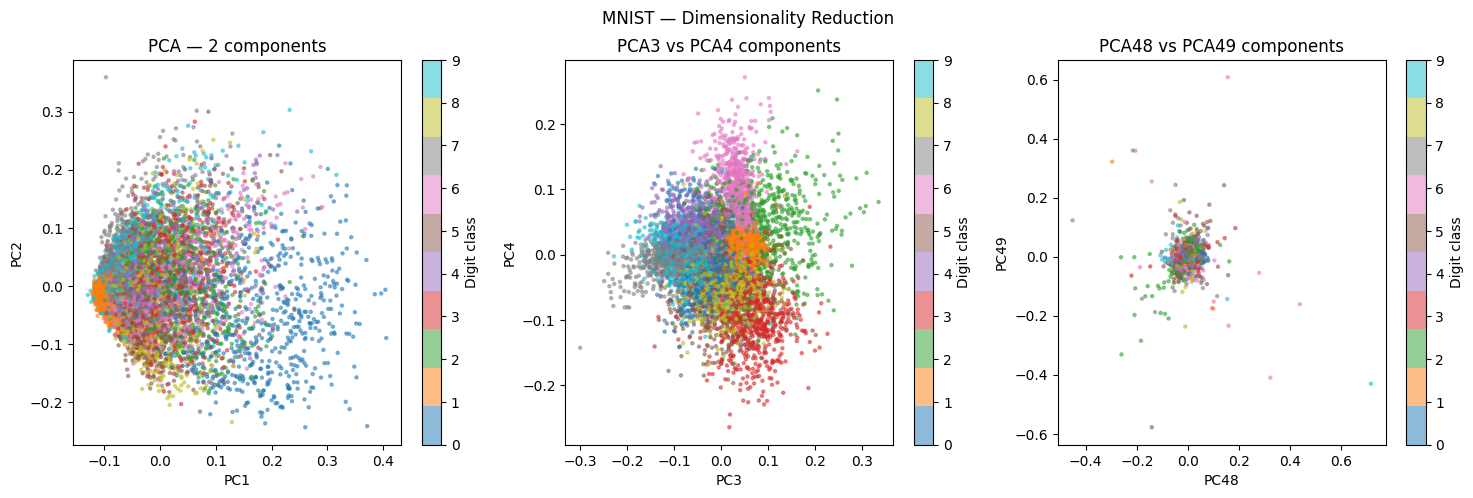

In [201]:
from sklearn.preprocessing import StandardScaler

#Need to Scale first! So that
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

kpca_poly = KernelPCA(n_components=50, kernel='poly', degree=2, gamma=0.0001, coef0=1)

kpca50_poly_train = kpca_poly.fit_transform(x_train_scaled)
kpca50_poly_test = kpca_poly.transform(x_test_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MNIST — Dimensionality Reduction")

# PCA1 v PCA2 scatter
sc1 = axes[0].scatter(kpca50_poly_train[:, 0], kpca50_poly_train[:, 1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[0].set_title("PCA — 2 components")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="Digit class")

# PCA3 v PCA4 scatter
sc1 = axes[1].scatter(kpca50_poly_train[:, 2], kpca50_poly_train[:, 3],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[1].set_title("PCA3 vs PCA4 components")
axes[1].set_xlabel("PC3"); axes[1].set_ylabel("PC4")
plt.colorbar(sc1, ax=axes[1], label="Digit class")

# PCA5 v PCA6 scatter
sc1 = axes[2].scatter(kpca50_poly_train[:, -2], kpca50_poly_train[:, -1],
                      c=y_train.values, cmap="tab10", s=5, alpha=0.5)
axes[2].set_title("PCA48 vs PCA49 components")
axes[2].set_xlabel("PC48"); axes[2].set_ylabel("PC49")
plt.colorbar(sc1, ax=axes[2], label="Digit class")

In [212]:
print(y_train)
print(np.ravel(y_train))

      label
8460      8
2212      2
820       0
5936      5
43        0
...     ...
2432      2
7373      7
3287      3
312       0
7627      7

[7000 rows x 1 columns]
[8 2 0 ... 3 0 7]


In [222]:
pca50_nowhiten = PCA(n_components=50, svd_solver='full', whiten=False)
pca50_nowhiten_train = pca50_nowhiten.fit_transform(x_train)
pca50_nowhiten_test = pca50_nowhiten.transform(x_test)



def evaluate_log_reg(X_train, X_test, y_train, y_test):
    model = LogisticRegression(max_iter=5000)
    model.fit(X_train, y_train.values.ravel())

    y_pred = model.predict(X_test)
    error_rate = np.mean(y_pred != np.ravel(y_test))
    confusion_mat = confusion_matrix(np.ravel(y_test),y_pred)
    return error_rate, confusion_mat

#Surprising that kPCA performs worse. Whitening seems to have little effect
#Overfitting????
results = {}
cms = {}

models = {
    "PCA": (pca50_train, pca50_test),
    "PCA_nowhiten": (pca50_nowhiten_train, pca50_nowhiten_test),
    "KernelPCA (rbf)": (kpca50_train, kpca50_test),
    "KernelPCA (poly)": (kpca50_poly_train, kpca50_poly_test),
}

for name, (train, test) in models.items():
    error_rate, cm = evaluate_log_reg(train, test, y_train, y_test)
    results[name] = error_rate
    cms[name] = cm



C:\Users\BetterOffBread\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'PCA': np.float64(0.101), 'PCA_nowhiten': np.float64(0.09866666666666667), 'KernelPCA (rbf)': np.float64(0.13833333333333334), 'KernelPCA (poly)': np.float64(0.16066666666666668)}


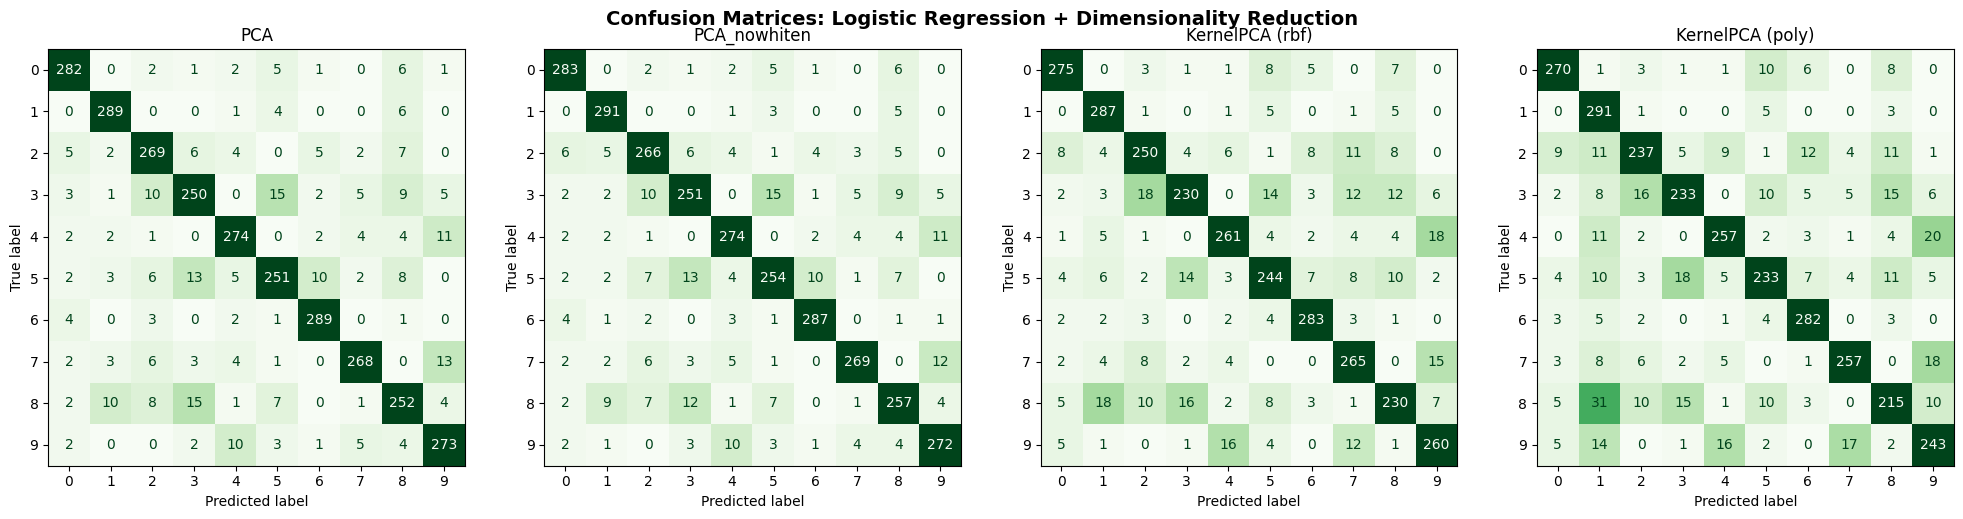

In [225]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, cm) in zip(axes, cms.items()):
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format="d")
    
    # Fix color scale for fair comparison
    im = ax.images[0]
    im.set_clim(0, 50)   # adjust depending on your dataset size
    
    ax.set_title(name)

print(results)

plt.suptitle("Confusion Matrices: Logistic Regression + Dimensionality Reduction",
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Set Up Gaussian Noise

In [224]:
percent = [.1,.5,.8]



## Evaluate Models